<a href="https://colab.research.google.com/github/renisha04/Machine-Learning-Lab/blob/main/ML_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Image Classification Using Convolutional Neural Network (CNN)

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [4]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("MNIST dataset loaded successfully!")
print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)


MNIST dataset loaded successfully!
Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)


In [5]:
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("\nImages normalized successfully!")


Images normalized successfully!


In [6]:

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nCNN model compiled successfully!")

model.summary()


CNN model compiled successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 54ms/step - accuracy: 0.9499 - loss: 0.1662 - val_accuracy: 0.9812 - val_loss: 0.0657
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 84s 57ms/step - accuracy: 0.9849 - loss: 0.0495 - val_accuracy: 0.9847 - val_loss: 0.0558
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 55ms/step - accuracy: 0.9893 - loss: 0.0340 - val_accuracy: 0.9870 - val_loss: 0.0497
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - accuracy: 0.9920 - loss: 0.0246 - val_accuracy: 0.9908 - val_loss: 0.0317
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 54ms/step - accuracy: 0.9937 - loss: 0.0191 - val_accuracy: 0.9898 - val_loss: 0.0363


In [9]:

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

In [10]:

print("\nCNN Classification Results")
print("--------------------------------")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy Percentage:", test_accuracy * 100, "%")


CNN Classification Results
--------------------------------
Test Loss: 0.026541106402873993
Test Accuracy: 0.9911999702453613
Test Accuracy Percentage: 99.11999702453613 %


In [11]:

predictions = model.predict(x_test[:5])

print("\nActual Labels:")
print(y_test[:5])

print("Predicted Labels:")
print(predictions.argmax(axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

Actual Labels:
[7 2 1 0 4]
Predicted Labels:
[7 2 1 0 4]


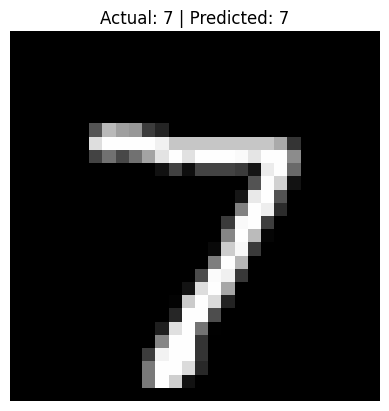


CNN image classification completed successfully!


In [12]:

plt.imshow(x_test[0].reshape(28, 28), cmap='gray')
plt.title(
    f"Actual: {y_test[0]} | Predicted: {predictions[0].argmax()}"
)
plt.axis("off")
plt.show()

print("\nCNN image classification completed successfully!")